# Day 04: Otomatik Veri Kalitesi Doğrulama ve Profilleme Hattı (Expectation Suites & Profiling)

> **Aşama:** Faz 1: Çevre & Veri Temelleri  
> **Konu:** Endüstriyel Veri Güvencesi, Deklaratif Beklentiler (Great Expectations Paradigması) ve Otomatik Profilleme  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-04  
> **Lisans:** Özel Lisans — Tüm Hakları Saklıdır

---

## 1. Problem Tanımı: Endüstriyel Veri Hatlarında Kalite ve Şema Sapması (Data Drift & Schema Drift)

Merinos halı fabrikasyon ortamında tezgâh telemetrisi (PLC logları), optik kalite kontrol kameraları, barkod okuyucular ve ERP katalog sistemlerinden her gün on binlerce kayıt toplanır.
Bu heterojen veri akışında:
- **Eksik Veri (Missing Data):** Sensör kopmaları veya kablosuz iletim gecikmeleri nedeniyle hav yüksekliği veya en-boy ölçüleri boş (`null` / `NaN`) gelebilir.
- **Mükerrer Kayıt (Duplicates):** Aynı parti malzemenin birden fazla tezgâhta mükerrer taranması veya ağ gecikmesiyle çift gönderilen HTTP paketleri veritabanını kirletir.
- **Fiziksel Kural İhlalleri (Out-of-Bounds):** Negatif veya 40 mm üzeri imkânsız hav yükseklikleri, izin verilmeyen hammadde kodları veya geçersiz hex renk paletleri downstream makine öğrenimi modellerini düşürür.
- **İstatistiksel Dağılım Kayması (Data Drift):** Tezgâh gergi mekanizmasındaki mekanik aşınma, ortalama hav yüksekliğini sistematik olarak 11 mm'den 18 mm'ye kaydırabilir. Model çıktısı bozulmasa bile fiziksel ürün defolu çıkar.

Bu notebook, **deklaratif veri beklentileri (Expectation Suites)** ve **otomatik istatistiksel profilleme** yöntemleriyle üretim hattı verilerini güvence altına almayı hedefler.

## 2. Neden Önemli? (Endüstriyel Etki & Model Güvenliği)

Geleneksel yazılımlarda birim testleri (unit tests) kodun doğruluğunu denetler; ancak makine öğrenmesi ve yapay zeka sistemlerinde davranış kod kadar **verinin kendisine** bağlıdır.

$$\text{Sistem Kalitesi} = f(\text{Algoritma Kod Kalitesi}) \times g(\text{Girdi Veri Kalitesi})$$

1. **Üretim Maliyeti:** Bozuk bir ürün kodu veya yanlış santimetre ölçüsü nedeniyle dokuma tezgâhına aktarılan hatalı parametreler, yüzlerce metrekarelik fire kumaşa yol açar.
2. **Çıkarım (Inference) Kararlılığı:** Day 02'de tasarladığımız Pydantic modelleri nesne seviyesinde tipleri korurken; Expectation Suites tablo ve dağılım seviyesinde (batch-level) istatistiksel sapmaları yakalar.
3. **Otomatik Uyarı & Observability:** Veri kalitesi anlık izlenerek bakım mühendislerine (örn. "Tezgâh 4 hav yüksekliği tolerans sınırını aştı") anında proaktif geri bildirim verilir.

## 3. Matematiksel & İstatistiksel Temeller

### 3.1. Hücre Bazlı Eksiklik Oranı (Missingness Rate, $\mathcal{M}$)
$$N \times P$ boyutundaki bir veri matrisinde toplam eksiklik oranı:
$$\mathcal{M} = \frac{1}{N \cdot P} \sum_{i=1}^N \sum_{j=1}^P \mathbb{I}(x_{ij} = \text{null})$$

### 3.2. Mükerrer Satır Oranı (Duplication Rate, $\mathcal{D}$)
$$\mathcal{D} = \frac{N_{\text{duplicate}}}{N}$$

### 3.3. Dağılım Ortalaması ve Drift Tespiti (Z-Score & Aralık Denetimi)
Bir özelliğin (örn. `pile_height_mm`) üretim partisi ortalaması $\bar{\mu}$:
$$\bar{\mu} = \frac{1}{n} \sum_{i=1}^n x_i$$
Eğer $\bar{\mu} \notin [\mu_{\min}, \mu_{\max}]$ ise süreç kontrol dışına çıkmıştır (Statistical Process Control / Shewhart Kuralı).

### 3.4. Bileşik Veri Kalite Skoru (Composite Data Quality Score, $Q$)
Boru hattımızda hesaplanan kümülatif kalite indisi:
$$Q = S_{\text{expectations}} \times (1 - \mathcal{M}) \times (1 - \mathcal{D})$$
Burada $S_{\text{expectations}} \in [0, 100]$ kuralların başarı yüzdesidir.

## 4. Kütüphane & Mimari İncelemesi (Great Expectations vs Pandera vs Custom Declarative Engine)

| Özellik | Great Expectations | Pandera | Custom Expectation Engine (Geliştirdiğimiz) |
| :--- | :--- | :--- | :--- |
| **Tasarım Yaklaşımı** | Deklaratif JSON/YAML Suite | Kod İçi Şema / Type Hints | Deklaratif JSON + Modüler Python Sınıfları |
| **Bağımlılık Yükü** | Ağır (SQLAlchemy, Click, Jinja, Cloud SDK) | Orta (Pandas, Pydantic, Typing) | Ultra Hafif (Sadece Pandas & NumPy) |
| **Bellek & Hız** | Orta / Ağır başlangıç gecikmesi | Hızlı | Maksimum Hız (Doğrudan Vektörize Pandas) |
| **Hata İzolasyonu** | Profil Raporu & Data Docs | Exception / Validation Error | `anomalous_records.csv` + JSON + HTML Paneli |
| **Taşınabilirlik** | Karmaşık klasör yapısı (`great_expectations/`) | Kod içine gömülü | Bağımsız JSON Şeması & Tek Dosya HTML Rapor |

Endüstriyel kenar (edge) cihazlarında ve izole fabrika sunucularında ağır bağımlılık yüklerinden kaçınmak için Great Expectations mimari prensiplerini taşıyan hafif, yüksek hızlı ve deklaratif bir motor tercih edilmiştir.

In [1]:
import sys
from pathlib import Path

# Dinamik kök dizin ve day04 dizin çözümü
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith('day') else CURRENT_DIR
DAY04_DIR = PROJECT_ROOT / 'day04'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
from day04.mini_project.src.expectations import (
    ExpectColumnValuesToNotBeNull,
    ExpectColumnValuesToBeUnique,
    ExpectColumnValuesToBeBetween,
    ExpectColumnValuesToBeInSet,
    ExpectColumnMeanToBeBetween,
)
from day04.mini_project.src.suite import ExpectationSuite, SuiteValidator

# Örnek mini DataFrame oluşturalım
sample_df = pd.DataFrame({
    "product_id": ["MRP-1001", "MRP-1002", "MRP-1003"],
    "material": ["wool", "acrylic", "bamboo"],
    "width_cm": [160.0, 200.0, 120.0],
    "pile_height_mm": [11.5, 12.0, 9.5]
})

# Deklaratif paket oluşturalım
suite = ExpectationSuite(suite_name="demo_production_suite")
suite.add_expectation(ExpectColumnValuesToNotBeNull(column="product_id"))
suite.add_expectation(ExpectColumnValuesToBeUnique(column="product_id"))
suite.add_expectation(ExpectColumnValuesToBeBetween(column="width_cm", min_value=60.0, max_value=350.0))
suite.add_expectation(ExpectColumnValuesToBeInSet(column="material", allowed_set=["wool", "acrylic", "bamboo"]))
suite.add_expectation(ExpectColumnMeanToBeBetween(column="pile_height_mm", min_value=8.0, max_value=15.0))

# Doğrulama çalıştıralım
result = SuiteValidator.validate(sample_df, suite)
print(f"Paket: {result.suite_name}")
print(f"Genel Başarı: {result.success}")
print(f"Başarım Oranı: %{result.statistics['success_percent']}")
print(f"Başarılı Kural: {result.statistics['successful_expectations']}/{result.statistics['evaluated_expectations']}")

Paket: demo_production_suite
Genel Başarı: True
Başarım Oranı: %100.0
Başarılı Kural: 5/5


In [2]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day04" else CURRENT_DIR
DAY_DIR = PROJECT_ROOT / "day04"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from pathlib import Path
from day04.mini_project.src.pipeline import DataQualityPipeline

# Üç farklı senaryoyu kıyaslayalım:
# 1. Temiz Referans Veri Seti (clean_production_data.csv)
# 2. Anomali Enjekte Edilmiş Veri Seti (dirty_production_data.csv)
# 3. Tezgâh Tansiyon Kayması Olan Veri Seti (drifted_production_data.csv)

fixtures_dir = DAY04_DIR / 'mini_project' / 'fixtures'
pipeline = DataQualityPipeline()

clean_res = pipeline.run(fixtures_dir / "clean_production_data.csv")
dirty_res = pipeline.run(fixtures_dir / "dirty_production_data.csv")
drift_res = pipeline.run(fixtures_dir / "drifted_production_data.csv")

comparison_df = pd.DataFrame([
    {
        "Senaryo": "Temiz Referans Veri",
        "Toplam Kayıt": clean_res["summary"]["total_records"],
        "Anomalili Kayıt": clean_res["summary"]["anomalous_records_count"],
        "Kural Başarımı (%)": clean_res["summary"]["statistics"]["success_percent"],
        "Bileşik Skor (%)": clean_res["summary"]["composite_quality_score"],
        "Durum": "ONAYLANDI" if clean_res["summary"]["validation_success"] else "REDDEDİLDİ"
    },
    {
        "Senaryo": "Anomali Enjeksiyonu",
        "Toplam Kayıt": dirty_res["summary"]["total_records"],
        "Anomalili Kayıt": dirty_res["summary"]["anomalous_records_count"],
        "Kural Başarımı (%)": dirty_res["summary"]["statistics"]["success_percent"],
        "Bileşik Skor (%)": dirty_res["summary"]["composite_quality_score"],
        "Durum": "ONAYLANDI" if dirty_res["summary"]["validation_success"] else "REDDEDİLDİ"
    },
    {
        "Senaryo": "Tezgâh Tansiyon Drifti",
        "Toplam Kayıt": drift_res["summary"]["total_records"],
        "Anomalili Kayıt": drift_res["summary"]["anomalous_records_count"],
        "Kural Başarımı (%)": drift_res["summary"]["statistics"]["success_percent"],
        "Bileşik Skor (%)": drift_res["summary"]["composite_quality_score"],
        "Durum": "ONAYLANDI" if drift_res["summary"]["validation_success"] else "REDDEDİLDİ"
    }
])

display(comparison_df)

,Senaryo,Toplam Kayıt,Anomalili Kayıt,Kural Başarımı (%),Bileşik Skor (%),Durum
0,Temiz Referans Veri,20,0,100.00,100.00,ONAYLANDI
1,Anomali Enjeksiyonu,20,16,26.67,26.27,REDDEDİLDİ
2,Tezgâh Tansiyon Drifti,20,0,93.33,93.33,REDDEDİLDİ


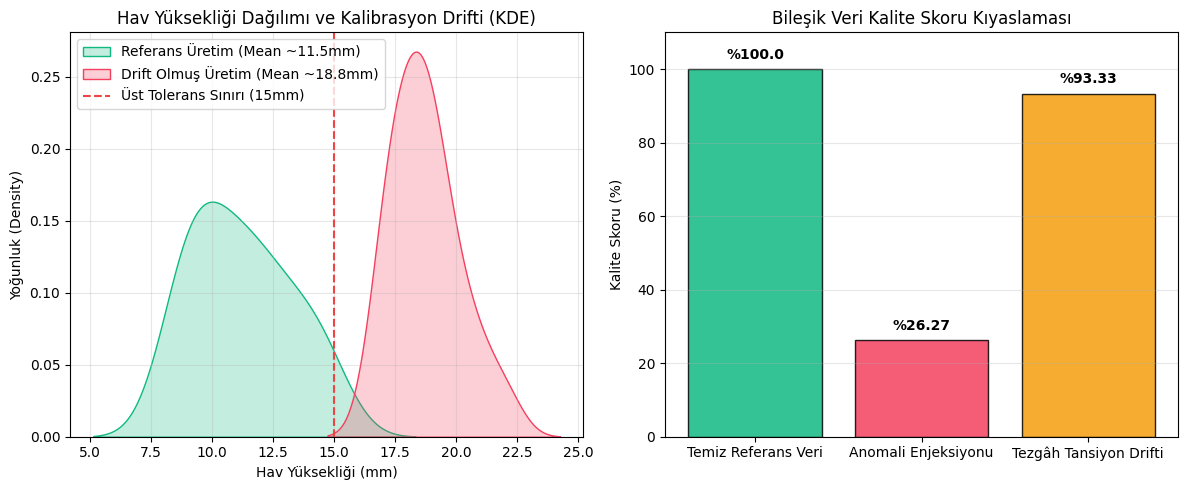

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Temiz ve Drift veri setlerinin hav yüksekliği dağılımlarını görselleştirelim
clean_df = pd.read_csv(fixtures_dir / "clean_production_data.csv")
drift_df = pd.read_csv(fixtures_dir / "drifted_production_data.csv")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(clean_df["pile_height_mm"], color="#10b981", fill=True, label="Referans Üretim (Mean ~11.5mm)")
sns.kdeplot(drift_df["pile_height_mm"], color="#f43f5e", fill=True, label="Drift Olmuş Üretim (Mean ~18.8mm)")
plt.axvline(15.0, color="#ef4444", linestyle="--", label="Üst Tolerans Sınırı (15mm)")
plt.title("Hav Yüksekliği Dağılımı ve Kalibrasyon Drifti (KDE)")
plt.xlabel("Hav Yüksekliği (mm)")
plt.ylabel("Yoğunluk (Density)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scenario_labels = comparison_df["Senaryo"].tolist()
scores = comparison_df["Bileşik Skor (%)"].tolist()
colors = ["#10b981", "#f43f5e", "#f59e0b"]
bars = plt.bar(scenario_labels, scores, color=colors, edgecolor="black", alpha=0.85)
plt.title("Bileşik Veri Kalite Skoru Kıyaslaması")
plt.ylabel("Kalite Skoru (%)")
plt.ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"%{yval}", ha="center", va="bottom", fontweight="bold")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Dirty veri setindeki spesifik kural ihlallerini listeleyelim
suite_config = DAY04_DIR / 'mini_project' / 'configs' / 'expectation_suite_config.json'
suite = ExpectationSuite.from_json(suite_config)
dirty_df = pd.read_csv(fixtures_dir / "dirty_production_data.csv")

val_res = SuiteValidator.validate(dirty_df, suite)
failed_expectations = [exp for exp in val_res.results if not exp.success]

print(f"Toplam {len(failed_expectations)} adet kural ihlali tespit edildi:\n")
for idx, exp in enumerate(failed_expectations, 1):
    kwargs_info = ", ".join([f"{k}={v}" for k, v in exp.kwargs.items()])
    print(f"{idx}. [{exp.expectation_type}] -> {kwargs_info}")
    print(f"   Mesaj: {exp.result.get('message')}")
    if exp.result.get('partial_unexpected_list'):
        print(f"   Örnek Hatalı Değerler: {exp.result['partial_unexpected_list'][:4]}")
    print("-" * 70)

Toplam 11 adet kural ihlali tespit edildi:

1. [expect_column_values_to_not_be_null] -> column=product_id, mostly=1.0
   Mesaj: 19/20 (95.0%) non-null (threshold: 100.0%)
   Örnek Hatalı Değerler: [None]
----------------------------------------------------------------------
2. [expect_column_values_to_be_unique] -> column=product_id
   Mesaj: Found 2 duplicate values in 'product_id'.
   Örnek Hatalı Değerler: ['MRP-1001', 'MRP-1001']
----------------------------------------------------------------------
3. [expect_column_values_to_match_regex] -> column=product_id, regex=^MRP-[0-9]{4}$
   Mesaj: 1 string values do not conform to regex pattern '^MRP-[0-9]{4}$'.
   Örnek Hatalı Değerler: ['INVALID_999']
----------------------------------------------------------------------
4. [expect_column_values_to_not_be_null] -> column=width_cm, mostly=1.0
   Mesaj: 19/20 (95.0%) non-null (threshold: 100.0%)
   Örnek Hatalı Değerler: [None]
------------------------------------------------------------

## 9. Hata Durumları, Edge Cases ve Drift Tespiti

1. **Eksik Sütun Durumu (Missing Column Edge Case):**
   - Beklenti tanımlı bir sütun DataFrame'de hiç bulunmadığında boru hattı çökmez (`KeyError` fırlatmaz); kural otomatik olarak `success=False` döner ve hata raporuna açıkça yansıtılır.
2. **Tek Elemanlı veya Boş Veri Seti:**
   - `ExpectTableRowCountToBeBetween` kuralı batch'in minimum kayıt gereksinimini denetler. Boş veya eksik aktarılmış veri kümeleri doğrudan yakalanır.
3. **Metin ve Regex Bozulmaları:**
   - `MRP-INVALID_999` ve `#12345` gibi regex desenini ihlal eden sahte kayıtlar başarıyla süzülür.
4. **Drift Tespiti:**
   - `drifted_production_data.csv` içinde hav yükseklikleri 16-22 mm arasına yükseldiğinde tek tek satır kontrolleri geçse bile `expect_column_mean_to_be_between` kuralı partiyi bloke eder.

## 10. Mühendislik Çıkarımları & Day 05'e Bağlantı

### Temel Çıkarımlar:
1. **Veri Kontratları (Data Contracts):** Pydantic tekil nesne doğrulamasında mükemmeldir; ancak toplu batch aktarımlarında dağılım ve tekillik denetimleri için deklaratif Expectation Suites şarttır.
2. **Anomali İzolasyonu:** Hatalı satırlar (`anomalous_records.csv`) boru hattını çökertmeden izole edilir, temiz veriler downstream derin öğrenme ve katalog servislerine güvenle akar.
3. **Gözlemlenebilirlik (Observability):** Üretilen tek dosyalık interaktif `data_quality_dashboard.html`, fabrika operatörlerine sıfır kurulum gereksinimiyle anlık görsel denetim sunar.

### Day 05'e Bağlantı:
Day 05'te (**NumPy Vektörize Operasyonlar ve Matris Hesaplama Laboratuvarı**), bu temizlenen sayısal veriler ve görsel matrisler üzerinde Python döngüleri yerine NumPy C-hızında broadcasting, tensör şekillendirme ve bellek düzeni (memory layout) optimizasyonları incelenecektir.